<a href="https://colab.research.google.com/github/andrewemmanuelyohanson31-ship-it/MLPClothing/blob/test/ResMedMLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)

## DATASET CORRELATION (Mean)

In [ ]:
SIZE_MAP_3 = {
    'XXS': 'S', 'XS': 'S', 'S': 'S',
    'M':   'M',
    'L':   'L', 'XL': 'L', 'XXL': 'L', 'XXXL': 'L'
}
SIZE_ORDER = ['S', 'M', 'L']


df_a = pd.read_csv('final_test.csv')
df_a['size_3'] = df_a['size'].map(SIZE_MAP_3)
df_a = df_a.dropna(subset=['size_3'])
df_a = df_a[
    (df_a['age']    >= 16) & (df_a['age']    <= 80)  &
    (df_a['height'] >= 140) & (df_a['height'] <= 210) &
    (df_a['weight'] >= 35)  & (df_a['weight'] <= 150)
]
feats_a = ['weight', 'age', 'height']


df_b = pd.read_csv('personalized_clothing_dataset.csv')
df_b['size_3'] = df_b['RecommendedSize'].map(SIZE_MAP_3)
df_b = df_b.dropna(subset=['size_3'])
feats_b = ['Weight_kg', 'Height_cm', 'Chest_cm', 'Waist_cm',
           'Hip_cm', 'ShoulderWidth_cm', 'Age']

print(f"\nDataset A (final_test.csv): {len(df_a):,} rows")
print(f"Dataset B (personalized_clothing):   {len(df_b):,} rows")


print("final_test.csv")
for i in feats_a:
    means = df_a.groupby('size_3')[i].mean()[SIZE_ORDER]
    print(f"  {i:12s}:  S={means['S']:.2f}  M={means['M']:.2f}  L={means['L']:.2f}")

print("personalized_clothing_dataset.csv")
for i in feats_b:
    means = df_b.groupby('size_3')[i].mean()[SIZE_ORDER]
    s, m, l = means['S'], means['M'], means['L']
    spread = max(s, m, l) - min(s, m, l)
    print(f"  {i:20s}:  S={s:.1f}  M={m:.1f}  L={l:.1f}")


Dataset A (final_test.csv): 119,011 rows
Dataset B (personalized_clothing):   1,000 rows
final_test.csv
  weight      :  S=53.00  M=58.21  L=68.38
  age         :  S=32.25  M=33.43  L=35.28
  height      :  S=163.01  M=165.50  L=167.51
personalized_clothing_dataset.csv
  Weight_kg           :  S=82.2  M=84.6  L=80.6
  Height_cm           :  S=175.1  M=175.0  L=173.5
  Chest_cm            :  S=100.6  M=99.2  L=99.9
  Waist_cm            :  S=89.7  M=90.8  L=90.6
  Hip_cm              :  S=109.1  M=110.4  L=110.5
  ShoulderWidth_cm    :  S=46.8  M=46.9  L=47.8
  Age                 :  S=38.0  M=38.4  L=39.4


Dataset A:
- Lots of rows -> better for MLP
- Reasonable average mean (S lebih kecil dari M, M lebih kecil dari L) -> correlated
- Reasonable numbers for each size

Dataset B:
- More body measurements (chest, waist, hip)
- Unreasonable average mean (weight: M > S > L) -> no correlation
- Unreasonable numbers for each size (weight, waist)

Jika dataset B tetap digunakan, maka bisa ada terjadi noise dan performa model akan menurun, jadi hanya dataset A yang akan digunakan

Nike backbone: 3000 rows
All brands:    18000 rows  (6 brands × 3 sizes × 1000)

Original dataset: 18000 rows  {'S': 6000, 'M': 6000, 'L': 6000}

Features: weight, age, height, BMI, W/H ratio
Train: 2400  |  Test: 600

Training backbone MLP …
  Backbone accuracy: 0.9550

Brand accuracy:
  H&M         acc=0.9347  macro-F1=0.9349  [Runs Small]
  Uniqlo      acc=0.9727  macro-F1=0.9726  [Slightly Small]
  Zara        acc=0.9533  macro-F1=0.9533  [Runs Small]
  GAP         acc=0.9607  macro-F1=0.9608  [Runs Large]
  Nike        acc=0.9713  macro-F1=0.9714  [True to Size]
  Levi's      acc=0.9630  macro-F1=0.9632  [True to Size]

Running 3-fold CV on backbone …
  Fold 1: 0.9650
  Fold 2: 0.9710
  Fold 3: 0.9710
  CV Mean ± Std: 0.9690 ± 0.0028


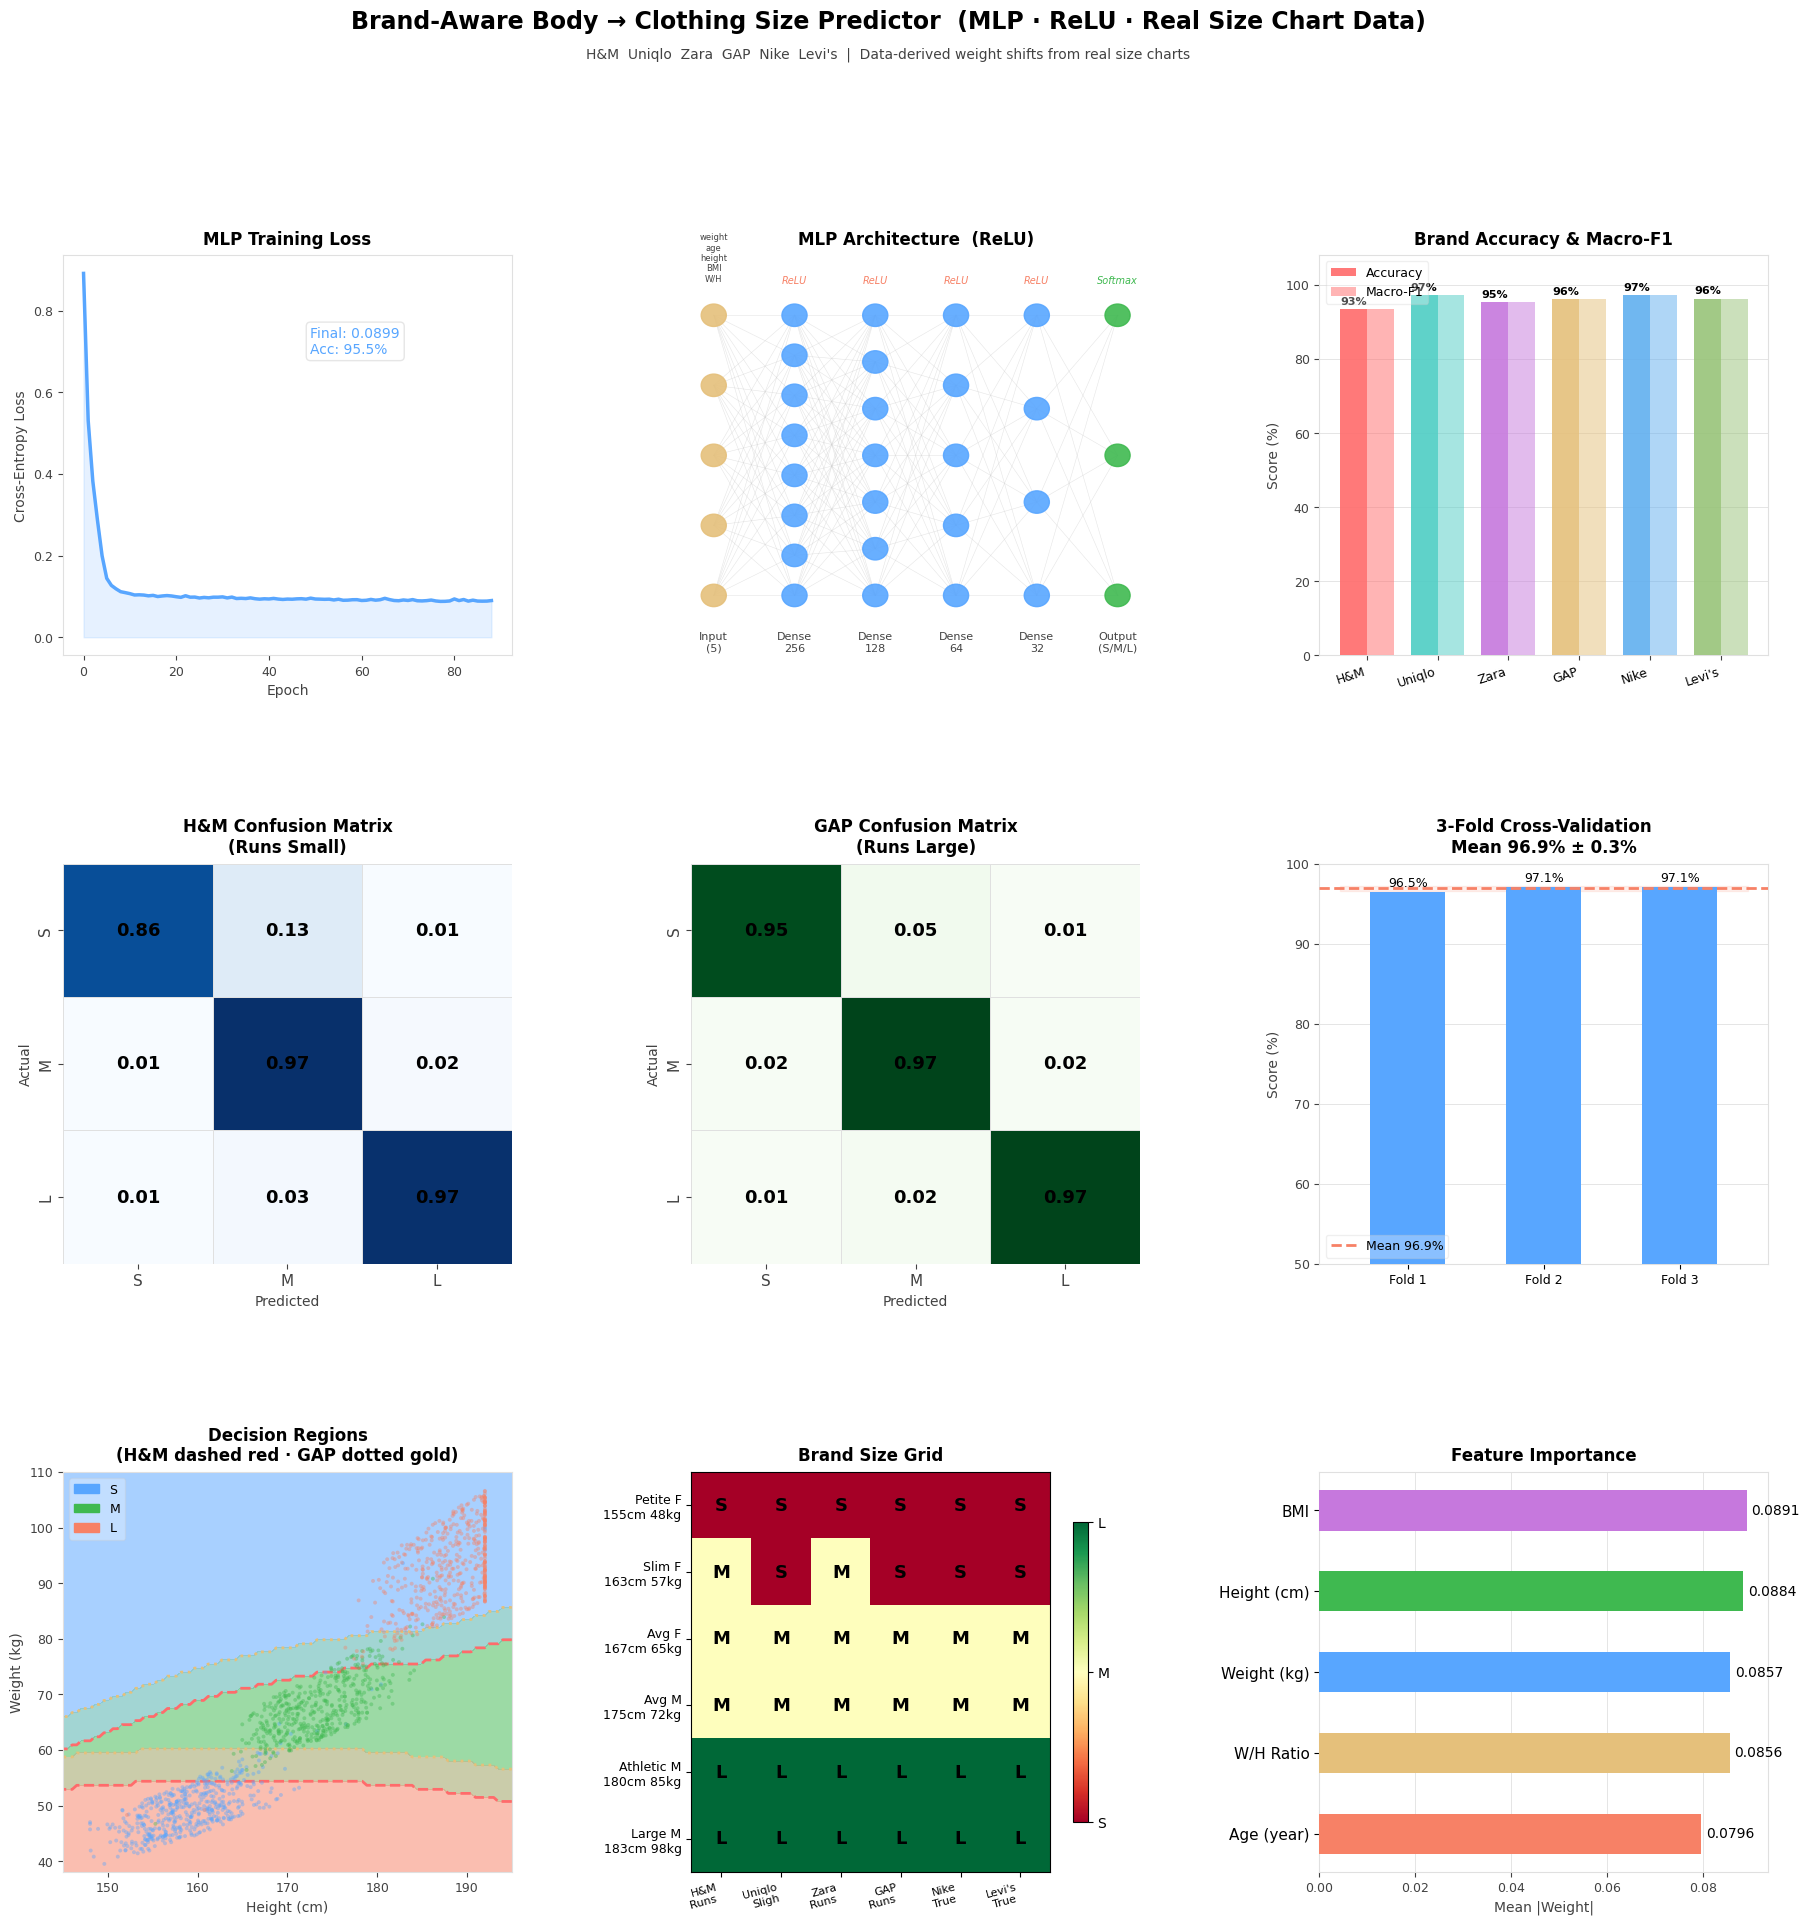


═══════════════════════════════════════════════════════
Classification Report
═══════════════════════════════════════════════════════
              precision    recall  f1-score   support

           S       0.95      0.98      0.97       198
           M       0.94      0.95      0.94       199
           L       0.98      0.94      0.96       203

    accuracy                           0.95       600
   macro avg       0.96      0.96      0.95       600
weighted avg       0.96      0.95      0.95       600


═══════════════════════════════════════════════════════
SAMPLE PREDICTIONS — body profiles × 6 brands
═══════════════════════════════════════════════════════
  Petite F 155cm 48kg  |  H&M→S  |  Uniqlo→S  |  Zara→S  |  GAP→S  |  Nike→S  |  Levi's→S
  Slim F 163cm 57kg  |  H&M→M  |  Uniqlo→S  |  Zara→M  |  GAP→S  |  Nike→S  |  Levi's→S
  Avg F 167cm 65kg  |  H&M→M  |  Uniqlo→M  |  Zara→M  |  GAP→M  |  Nike→M  |  Levi's→M
  Avg M 175cm 72kg  |  H&M→M  |  Uniqlo→M  |  Zara→M  |  GAP

In [ ]:
warnings.filterwarnings("ignore")
np.random.seed(42)

try:
    script_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    script_dir = os.getcwd()
outputs_dir = os.path.join(script_dir, 'outputs')
os.makedirs(outputs_dir, exist_ok=True)

SIZE_ORDER = ['S', 'M', 'L']
BRANDS     = ['H&M', 'Uniqlo', 'Zara', 'GAP', 'Nike', "Levi's"]

# weight_shift values are from weight difference per size class relative to Nike (baseline).
# Positive shift = brand runs SMALL
# - weight shifted UP before prediction
# - model sees heavier person → predicts larger size
# - effectively gives customer a bigger size recommendation
#
# Negative shift = brand runs LARGE
# - weight shifted DOWN before prediction
# - model sees lighter person → predicts smaller size
# - effectively gives customer a smaller size recommendation

BRAND_CONFIG = {
    'H&M':    {'weight_shift': +3.4, 'color': '#FF6B6B', 'label': 'Runs Small'},
    'Uniqlo': {'weight_shift': +0.6, 'color': '#4ECDC4', 'label': 'Slightly Small'},
    'Zara':   {'weight_shift': +3.8, 'color': '#C678DD', 'label': 'Runs Small'},
    'GAP':    {'weight_shift': -2.4, 'color': '#E5C07B', 'label': 'Runs Large'},
    'Nike':   {'weight_shift':  0.0, 'color': '#61AFEF', 'label': 'True to Size'},
    "Levi's": {'weight_shift': -1.0, 'color': '#98C379', 'label': 'True to Size'},
}

# ════════════════════════════════════════════════
# 1. INLINE BRAND DATA GENERATION
# ════════════════════════════════════════════════

#Brand size chart (chest/bust) in cm
BRAND_CHARTS = {
    'H&M':    {'S': (82, 87), 'M': (88,  93), 'L': (94,  99)},
    'Uniqlo': {'S': (79, 87), 'M': (88,  96), 'L': (97, 105)},
    'Zara':   {'S': (80, 86), 'M': (87,  93), 'L': (94, 100)},
    'GAP':    {'S': (84, 90), 'M': (91,  97), 'L': (98, 107)},
    'Nike':   {'S': (81, 88), 'M': (89,  96), 'L': (97, 104)},
    "Levi's": {'S': (83, 89), 'M': (90,  96), 'L': (97, 105)},
}
#BMI ranges: S=17.5-21.5, M=20.5-24.5, L=23.5-29.0
BMI_RANGES = {'S': (17.5, 21.5), 'M': (20.5, 24.5), 'L': (23.5, 29.0)}

def generate_brand_data(n_per_size=1000, noise_rate=0.02):
    """
    Generate brand-labeled height+weight data from real size charts.
    Nike is used as the backbone training set (True to Size = reference).
    Returns df_nike (backbone) and df_all_brands (for evaluation).
    """
    rows = []
    for brand, chart in BRAND_CHARTS.items():
        for size in ['S', 'M', 'L']:
            bust_lo, bust_hi    = chart[size]
            bmi_lo,  bmi_hi     = BMI_RANGES[size]
            n = n_per_size

            #chest ≈ 0.533 × height
            bust   = np.random.uniform(bust_lo, bust_hi, n)
            height = np.clip(bust / 0.533 + np.random.normal(0, 2.5, n), 148, 192)

            #BMI × (height/100)²
            bmi    = np.random.uniform(bmi_lo, bmi_hi, n)
            weight = np.clip(bmi * (height / 100) ** 2, 38, 130)

            age    = np.clip(np.random.normal(28, 8, n), 16, 65)

            #2% purchase noise (returns, wrong self-reported sizes)
            noise_mask  = np.random.random(n) < noise_rate
            final_sizes = np.where(
                noise_mask,
                np.random.choice(['S', 'M', 'L'], n),
                size
            )

            for i in range(n):
                rows.append({
                    'weight': round(float(weight[i]), 1),
                    'height': round(float(height[i]), 2),
                    'age':    int(age[i]),
                    'size_3': final_sizes[i],
                    'brand':  brand,
                })

    df_all    = pd.DataFrame(rows)
    df_nike   = df_all[df_all['brand'] == 'Nike'].reset_index(drop=True)
    return df_nike, df_all

df_nike, df_all_brands = generate_brand_data(n_per_size=1000, noise_rate=0.02)
print(f"Nike backbone: {len(df_nike)} rows")
print(f"All brands:    {len(df_all_brands)} rows  ({len(BRANDS)} brands × 3 sizes × 1000)")

# ════════════════════════════════════════════════
# 2. DATA CLEANING
# ════════════════════════════════════════════════

SIZE_MAP_3 = {
    'XXS': 'S', 'XS': 'S', 'S': 'S',
    'M':   'M',
    'L':   'L', 'XL': 'L', 'XXL': 'L', 'XXXL': 'L'
}

data_path = os.path.join(script_dir, 'final_test.csv')

df_raw = pd.read_csv(data_path).dropna()
df_raw['size_3'] = df_raw['size'].map(SIZE_MAP_3)
df_raw = df_raw.dropna(subset=['size_3'])
df_raw = df_raw[
    (df_raw['age']    >= 16) & (df_raw['age']    <= 80)  &
    (df_raw['height'] >= 140) & (df_raw['height'] <= 210) &
    (df_raw['weight'] >= 35)  & (df_raw['weight'] <= 150)
]

#balance for reference / visualization
n_per_class = 6000
frames = [
    df_raw[df_raw['size_3'] == sz].sample(
        min(len(df_raw[df_raw['size_3'] == sz]), n_per_class), random_state=42
    )
    for sz in SIZE_ORDER
]
df_orig = pd.concat(frames).reset_index(drop=True)
print(f"\nOriginal dataset: {len(df_orig)} rows  "
      f"{df_orig['size_3'].value_counts().to_dict()}")

# ════════════════════════════════════════════════
# FEATURE ENGINEERING
# ════════════════════════════════════════════════

def add_features(X):
    """
    Input:  X  columns [weight, age, height]
    Output: X  columns [weight, age, height, BMI, W/H ratio]
    """
    weight = X[:, 0]
    height = X[:, 2]
    bmi      = weight / (height / 100) ** 2
    wh_ratio = weight / height
    return np.c_[X, bmi, wh_ratio]

def add_features_shifted(X_raw, weight_shift):
    """
    Apply brand weight shift THEN recalculate derived features.
    Only raw 3-column input [weight, age, height] is accepted.
    """
    X_shifted        = X_raw.copy()
    X_shifted[:, 0] += weight_shift
    weight   = X_shifted[:, 0]
    height   = X_shifted[:, 2]
    bmi      = weight / (height / 100) ** 2
    wh_ratio = weight / height
    return np.c_[X_shifted, bmi, wh_ratio]

#Nike backbone training data
X_nike = add_features(df_nike[['weight', 'age', 'height']].values.astype(float))
y_nike = df_nike['size_3'].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_nike, y_nike, test_size=0.20, random_state=42, stratify=y_nike
)

print(f"\nFeatures: weight, age, height, BMI, W/H ratio")
print(f"Train: {len(X_tr)}  |  Test: {len(X_te)}")

# ════════════════════════════════════════════════
# 3. MLP BACKBONE  (Nike — True to Size reference)
# ════════════════════════════════════════════════

backbone = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(256, 128, 64, 32),
        activation='relu',
        solver='adam',
        max_iter=200,
        random_state=42,
        learning_rate_init=0.001,
        batch_size=256,
    ))
])

print("\nTraining backbone MLP …")
backbone.fit(X_tr, y_tr)
base_acc = accuracy_score(y_te, backbone.predict(X_te))
print(f"  Backbone accuracy: {base_acc:.4f}")

loss_curve = backbone.named_steps['mlp'].loss_curve_

# ════════════════════════════════════════════════
# 4. BRAND CALIBRATION
# ════════════════════════════════════════════════

def brand_predict_proba(X_raw, brand):
    """Return calibrated class probabilities for a brand.
    X_raw: numpy array with columns [weight, age, height]
    """
    shift = BRAND_CONFIG[brand]['weight_shift']
    X_eng = add_features_shifted(X_raw, shift)
    return backbone.predict_proba(X_eng)

def brand_predict(X_raw, brand):
    proba = brand_predict_proba(X_raw, brand)
    return backbone.classes_[np.argmax(proba, axis=1)]


print("\nBrand accuracy:")
brand_accs, brand_f1s = {}, {}
for brand in BRANDS:
    df_b  = df_all_brands[df_all_brands['brand'] == brand]
    X_b   = df_b[['weight', 'age', 'height']].values.astype(float)
    y_b   = df_b['size_3'].values
    preds = brand_predict(X_b, brand)
    acc   = accuracy_score(y_b, preds)
    mf1   = f1_score(y_b, preds, labels=SIZE_ORDER, average='macro')
    brand_accs[brand] = acc
    brand_f1s[brand]  = mf1
    print(f"  {brand:10s}  acc={acc:.4f}  macro-F1={mf1:.4f}  [{BRAND_CONFIG[brand]['label']}]")

# ════════════════════════════════════════════════
# 5. CROSS VALIDATION
# ════════════════════════════════════════════════

print("\nRunning 3-fold CV on backbone …")
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_scores = []
for fold, (tr_idx, va_idx) in enumerate(cv.split(X_nike, y_nike)):
    m = Pipeline([('sc', StandardScaler()),
                  ('mlp', MLPClassifier(
                      hidden_layer_sizes=(256, 128, 64, 32),
                      activation='relu', solver='adam',
                      max_iter=150, random_state=42
                  ))])
    m.fit(X_nike[tr_idx], y_nike[tr_idx])
    cv_scores.append(accuracy_score(y_nike[va_idx], m.predict(X_nike[va_idx])))
    print(f"  Fold {fold+1}: {cv_scores[-1]:.4f}")
print(f"  CV Mean ± Std: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

# ════════════════════════════════════════════════
# 6. VISUALISATION
# ════════════════════════════════════════════════

BG    = '#FFFFFF'
CARD  = '#FFFFFF'
GRID  = '#E0E0E0'
WHITE = '#000000'
MUTED = '#424242'
ACCENT = {'S': '#58A6FF', 'M': '#3FB950', 'L': '#F78166'}

def style_ax(ax, xgrid=False, ygrid=True):
    ax.set_facecolor(CARD)
    ax.tick_params(colors=MUTED, labelsize=9)
    for sp in ax.spines.values():
        sp.set_color(GRID)
    if ygrid:
        ax.grid(axis='y', color=GRID, linewidth=0.6, zorder=0)
    if xgrid:
        ax.grid(axis='x', color=GRID, linewidth=0.6, zorder=0)

TK = dict(color=WHITE, fontsize=12, fontweight='bold', pad=8)
LK = dict(color=MUTED, fontsize=10)

fig = plt.figure(figsize=(22, 21))
fig.patch.set_facecolor(BG)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.52, wspace=0.40)

#Loss Curve: Did the network learn smoothly?
ax = fig.add_subplot(gs[0, 0])
style_ax(ax, ygrid=False)
ax.plot(loss_curve, color='#58A6FF', lw=2.5)
ax.fill_between(range(len(loss_curve)), loss_curve, alpha=0.15, color='#58A6FF')
ax.set_title('MLP Training Loss', **TK)
ax.set_xlabel('Epoch', **LK)
ax.set_ylabel('Cross-Entropy Loss', **LK)
ax.text(len(loss_curve) * 0.55, max(loss_curve) * 0.78,
        f'Final: {loss_curve[-1]:.4f}\nAcc: {base_acc:.1%}',
        color='#58A6FF', fontsize=10,
        bbox=dict(boxstyle='round', fc=CARD, ec=GRID, alpha=0.8))

#Network Architecture: Visual of the neuron layers
ax = fig.add_subplot(gs[0, 1])
ax.set_facecolor(CARD)
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('MLP Architecture  (ReLU)', **TK)

layers   = [5, 8, 7, 5, 4, 3]
l_labels = ['Input\n(5)', 'Dense\n256', 'Dense\n128', 'Dense\n64', 'Dense\n32', 'Output\n(S/M/L)']
l_colors = ['#E5C07B', '#58A6FF', '#58A6FF', '#58A6FF', '#58A6FF', '#3FB950']
xs = np.linspace(0.5, 9.5, len(layers))

node_positions = []
for i, (x, n) in enumerate(zip(xs, layers)):
    ys = np.linspace(1.5, 8.5, n)
    node_positions.append(list(zip([x] * n, ys)))
    for y_pos in ys:
        circ = plt.Circle((x, y_pos), 0.28, color=l_colors[i], zorder=3, alpha=0.9)
        ax.add_patch(circ)
    ax.text(x, 0.6, l_labels[i], ha='center', va='top', color=MUTED, fontsize=8)

for i in range(len(layers) - 1):
    for (x1, y1) in node_positions[i]:
        for (x2, y2) in node_positions[i + 1]:
            ax.plot([x1, x2], [y1, y2], color='#CCCCCC', lw=0.4, zorder=1, alpha=0.5)

for i in range(1, len(layers) - 1):
    ax.text(xs[i], 9.3, 'ReLU', ha='center', color='#F78166', fontsize=7, style='italic')
ax.text(xs[-1], 9.3, 'Softmax', ha='center', color='#3FB950', fontsize=7, style='italic')
ax.text(xs[0], 9.3, 'weight\nage\nheight\nBMI\nW/H',
        ha='center', color=MUTED, fontsize=6, va='bottom')

#Brand Accuracy Comparison: Which brand predictions are most accurate
ax = fig.add_subplot(gs[0, 2])
style_ax(ax)
x     = np.arange(len(BRANDS))
w     = 0.38
c_acc = [BRAND_CONFIG[b]['color'] for b in BRANDS]
bars1 = ax.bar(x - w/2, [brand_accs[b] * 100 for b in BRANDS], w,
               color=c_acc, alpha=0.9, edgecolor='none', zorder=3, label='Accuracy')
bars2 = ax.bar(x + w/2, [brand_f1s[b]  * 100 for b in BRANDS], w,
               color=c_acc, alpha=0.5, edgecolor='none', zorder=3, label='Macro-F1',
               hatch='///')
for bar, val in zip(bars1, [brand_accs[b] * 100 for b in BRANDS]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
            f'{val:.0f}%', ha='center', va='bottom', color=WHITE,
            fontsize=8, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(BRANDS, color=WHITE, fontsize=9, rotation=18, ha='right')
ax.set_ylim(0, 108)
ax.set_ylabel('Score (%)', **LK)
ax.set_title('Brand Accuracy & Macro-F1', **TK)
ax.legend(framealpha=0.3, labelcolor=WHITE, fontsize=9)

#Confusion Matrix: H&M
ax = fig.add_subplot(gs[1, 0])
ax.set_facecolor(CARD)
df_hm  = df_all_brands[df_all_brands['brand'] == 'H&M']
X_hm   = df_hm[['weight', 'age', 'height']].values.astype(float)
y_hm   = df_hm['size_3'].values
cm_hm  = confusion_matrix(y_hm, brand_predict(X_hm, 'H&M'), labels=SIZE_ORDER)
cm_hm_n = cm_hm.astype(float) / cm_hm.sum(axis=1, keepdims=True)
sns.heatmap(cm_hm_n, annot=True, fmt='.2f', cmap='Blues', ax=ax,
            xticklabels=SIZE_ORDER, yticklabels=SIZE_ORDER,
            linewidths=0.5, linecolor=GRID, cbar=False,
            annot_kws={'size': 13, 'color': WHITE, 'weight': 'bold'})
ax.set_title(f'H&M Confusion Matrix\n({BRAND_CONFIG["H&M"]["label"]})', **TK)
ax.set_xlabel('Predicted', **LK)
ax.set_ylabel('Actual', **LK)
ax.tick_params(colors=MUTED, labelsize=11)

#Confusion Matrix: GAP
ax = fig.add_subplot(gs[1, 1])
ax.set_facecolor(CARD)
df_gap  = df_all_brands[df_all_brands['brand'] == 'GAP']
X_gap   = df_gap[['weight', 'age', 'height']].values.astype(float)
y_gap   = df_gap['size_3'].values
cm_gap  = confusion_matrix(y_gap, brand_predict(X_gap, 'GAP'), labels=SIZE_ORDER)
cm_gap_n = cm_gap.astype(float) / cm_gap.sum(axis=1, keepdims=True)
sns.heatmap(cm_gap_n, annot=True, fmt='.2f', cmap='Greens', ax=ax,
            xticklabels=SIZE_ORDER, yticklabels=SIZE_ORDER,
            linewidths=0.5, linecolor=GRID, cbar=False,
            annot_kws={'size': 13, 'color': WHITE, 'weight': 'bold'})
ax.set_title(f'GAP Confusion Matrix\n({BRAND_CONFIG["GAP"]["label"]})', **TK)
ax.set_xlabel('Predicted', **LK)
ax.set_ylabel('Actual', **LK)
ax.tick_params(colors=MUTED, labelsize=11)

#Cross Validation: Is accuracy consistent across different data splits?
ax = fig.add_subplot(gs[1, 2])
style_ax(ax)
fold_labels = [f'Fold {i+1}' for i in range(len(cv_scores))]
bars = ax.bar(fold_labels, [s * 100 for s in cv_scores],
              color='#58A6FF', edgecolor='none', zorder=3, width=0.55)
ax.axhline(np.mean(cv_scores) * 100, color='#F78166', lw=2, linestyle='--',
           zorder=4, label=f'Mean {np.mean(cv_scores):.1%}')
ax.fill_between([-0.5, len(cv_scores) - 0.5],
                [(np.mean(cv_scores) - np.std(cv_scores)) * 100] * 2,
                [(np.mean(cv_scores) + np.std(cv_scores)) * 100] * 2,
                color='#F78166', alpha=0.12, zorder=2)
for bar, val in zip(bars, cv_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.1%}', ha='center', va='bottom', color=WHITE, fontsize=9)
ax.set_ylim(50, 100)
ax.set_ylabel('Score (%)', **LK)
ax.set_title(f'3-Fold Cross-Validation\nMean {np.mean(cv_scores):.1%} ± {np.std(cv_scores):.1%}',
             **TK)
ax.tick_params(axis='x', colors=WHITE)
ax.legend(framealpha=0.3, labelcolor=WHITE, fontsize=9)

#Decision Boundary: Visual map of where S/M/L boundaries fall
ax = fig.add_subplot(gs[2, 0])
style_ax(ax, ygrid=False)
h_grid   = np.linspace(145, 195, 100)
w_grid   = np.linspace(38,  110, 100)
HH, WW   = np.meshgrid(h_grid, w_grid)
grid_raw = np.c_[WW.ravel(), np.full(WW.size, 30), HH.ravel()].astype(float)

for brand, alpha in [('H&M', 0.35), ('GAP', 0.25)]:
    proba = brand_predict_proba(grid_raw, brand)
    Z     = np.argmax(proba, axis=1).reshape(HH.shape)
    ax.contourf(HH, WW, Z, alpha=alpha, levels=[-0.5, 0.5, 1.5, 2.5],
                colors=[ACCENT['S'] + '44', ACCENT['M'] + '44', ACCENT['L'] + '44'])

proba_hm = brand_predict_proba(grid_raw, 'H&M')
Z_hm     = np.argmax(proba_hm, axis=1).reshape(HH.shape)
ax.contour(HH, WW, Z_hm, levels=[0.5, 1.5],
           colors=['#FF6B6B'], linewidths=2, linestyles='--')

proba_gap = brand_predict_proba(grid_raw, 'GAP')
Z_gap     = np.argmax(proba_gap, axis=1).reshape(HH.shape)
ax.contour(HH, WW, Z_gap, levels=[0.5, 1.5],
           colors=['#E5C07B'], linewidths=2, linestyles=':')

#scatter from Nike data
sample = df_nike.sample(1500, random_state=7)
for sz in SIZE_ORDER:
    mask = sample['size_3'] == sz
    ax.scatter(sample['height'].values[mask], sample['weight'].values[mask],
               c=ACCENT[sz], alpha=0.4, s=8, label=sz, edgecolors='none', zorder=3)
ax.set_title('Decision Regions\n(H&M dashed red · GAP dotted gold)', **TK)
ax.set_xlabel('Height (cm)', **LK)
ax.set_ylabel('Weight (kg)', **LK)
leg_patches = [mpatches.Patch(color=ACCENT[s], label=s) for s in SIZE_ORDER]
ax.legend(handles=leg_patches, framealpha=0.3, labelcolor=WHITE, fontsize=9)

#Brand Size Grid: Same person, different size across brands
ax = fig.add_subplot(gs[2, 1])
ax.set_facecolor(CARD)

profiles = [
    ('Petite F\n155cm 48kg',   [48, 23, 155]),
    ('Slim F\n163cm 57kg',     [57, 27, 163]),
    ('Avg F\n167cm 65kg',      [65, 30, 167]),
    ('Avg M\n175cm 72kg',      [72, 32, 175]),
    ('Athletic M\n180cm 85kg', [85, 28, 180]),
    ('Large M\n183cm 98kg',    [98, 38, 183]),
]
s2n = {'S': 0, 'M': 1, 'L': 2}
n2s = {0: 'S', 1: 'M', 2: 'L'}

grid_mat = np.zeros((len(profiles), len(BRANDS)))
for pi, (_, body) in enumerate(profiles):
    X_body = np.array([body], dtype=float)
    for bi, brand in enumerate(BRANDS):
        pred            = brand_predict(X_body, brand)[0]
        grid_mat[pi, bi] = s2n[pred]

im = ax.imshow(grid_mat, cmap='RdYlGn', vmin=0, vmax=2, aspect='auto')
for pi in range(len(profiles)):
    for bi in range(len(BRANDS)):
        val = n2s[int(grid_mat[pi, bi])]
        ax.text(bi, pi, val, ha='center', va='center',
                color=WHITE, fontsize=13, fontweight='bold')

ax.set_xticks(range(len(BRANDS)))
ax.set_xticklabels([f'{b}\n{BRAND_CONFIG[b]["label"][:5]}' for b in BRANDS],
                   color=WHITE, fontsize=8, rotation=15, ha='right')
ax.set_yticks(range(len(profiles)))
ax.set_yticklabels([p[0] for p in profiles], color=WHITE, fontsize=9)
ax.set_title('Brand Size Grid', **TK)
cbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2], shrink=0.75)
cbar.ax.set_yticklabels(['S', 'M', 'L'], color=WHITE, fontsize=10)
cbar.ax.tick_params(colors=WHITE)

#Feature Importance: Weight matters most, then height, then age
ax = fig.add_subplot(gs[2, 2])
style_ax(ax, xgrid=True, ygrid=False)
w1         = np.abs(backbone.named_steps['mlp'].coefs_[0])  # shape (5, 256)
importance = w1.mean(axis=1)
feat_labels = ['Weight (kg)', 'Age (year)', 'Height (cm)', 'BMI', 'W/H Ratio']
sorted_idx  = np.argsort(importance)
bar_colors  = ['#58A6FF', '#F78166', '#3FB950', '#C678DD', '#E5C07B']

bars = ax.barh(
    [feat_labels[i] for i in sorted_idx],
    importance[sorted_idx],
    color=[bar_colors[i % len(bar_colors)] for i in sorted_idx],
    edgecolor='none', zorder=3, height=0.5
)
for bar, val in zip(bars, importance[sorted_idx]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', color=WHITE, fontsize=10)
ax.set_title('Feature Importance', **TK)
ax.set_xlabel('Mean |Weight|', **LK)
ax.tick_params(axis='y', colors=WHITE, labelsize=11)

#Master title
fig.text(0.5, 0.997,
         'Brand-Aware Body → Clothing Size Predictor  (MLP · ReLU · Real Size Chart Data)',
         ha='center', va='top', color=WHITE, fontsize=17, fontweight='bold')
fig.text(0.5, 0.979,
         '  '.join(BRANDS) + '  |  Data-derived weight shifts from real size charts',
         ha='center', va='top', color=MUTED, fontsize=10)

plt.show()

# ════════════════════════════════════════════════
# 7. EVALUATION
# ════════════════════════════════════════════════

print("\n" + "═" * 55)
print("Classification Report")
print("═" * 55)
print(classification_report(y_te, backbone.predict(X_te), target_names=SIZE_ORDER))

print("\n" + "═" * 55)
print("SAMPLE PREDICTIONS — body profiles × 6 brands")
print("═" * 55)
for label, body in profiles:
    row    = [label.replace('\n', ' ')]
    X_body = np.array([body], dtype=float)
    for brand in BRANDS:
        p = brand_predict(X_body, brand)[0]
        row.append(f'{brand}→{p}')
    print('  ' + '  |  '.join(row))

## Other Baseline Models Comparison

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# Check if X_tr, y_tr, X_te, y_te, and base_acc are defined from previous cells
if 'X_tr' not in globals() or 'y_tr' not in globals() or 'X_te' not in globals() or 'y_te' not in globals() or 'base_acc' not in globals():
    print("Error: Variables for training data (X_tr, y_tr, X_te, y_te) or MLP baseline accuracy (base_acc) are not defined.")
    print("Please ensure that all preceding cells, especially the 'MLP BACKBONE' section (cell `n1uWXo__8cKq`), have been executed.")
    raise RuntimeError("Prerequisite variables (X_tr, y_tr, X_te, y_te, base_acc) not found.")

def train_and_evaluate_model(model, X_train, y_train, X_test, y_test, scaler=None):
    """Trains and evaluates a given model."""
    pipeline_steps = []
    if scaler:
        pipeline_steps.append(('scaler', scaler))
    pipeline_steps.append(('model', model))

    pipeline = Pipeline(pipeline_steps)
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    return accuracy

results = {}

#Logistic Regression
print("\nTraining Logistic Regression…")
log_reg_acc = train_and_evaluate_model(
    LogisticRegression(max_iter=500, random_state=42),
    X_tr, y_tr, X_te, y_te, StandardScaler()
)
results['Logistic Regression'] = log_reg_acc
print(f"  Logistic Regression accuracy: {log_reg_acc:.4f}")

#Random Forest
print("\nTraining Random Forest…")
rf_acc = train_and_evaluate_model(
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_tr, y_tr, X_te, y_te, StandardScaler()
)
results['Random Forest'] = rf_acc
print(f"  Random Forest accuracy: {rf_acc:.4f}")

#SVM
print("\nTraining SVM…")
svm_acc = train_and_evaluate_model(
    SVC(random_state=42),
    X_tr, y_tr, X_te, y_te, StandardScaler()
)
results['SVM'] = svm_acc
print(f"  SVM accuracy: {svm_acc:.4f}")

#KNN
print("\nTraining KNN…")
knn_acc = train_and_evaluate_model(
    KNeighborsClassifier(n_neighbors=5),
    X_tr, y_tr, X_te, y_te, StandardScaler()
)
results['KNN'] = knn_acc
print(f"  KNN accuracy: {knn_acc:.4f}")

#MLP
results['MLP Backbone'] = base_acc


Training Logistic Regression…
  Logistic Regression accuracy: 0.9567

Training Random Forest…
  Random Forest accuracy: 0.9600

Training SVM…
  SVM accuracy: 0.9567

Training KNN…
  KNN accuracy: 0.9600


### Model Performance Comparison

Here's a comparison of the trained models based on their accuracy on the test set:


In [ ]:
import pandas as pd
from IPython.display import display

# Check if results dictionary is defined from previous cell
if 'results' not in globals():
    print("Error: 'results' dictionary is not defined.")
    print("Please ensure that the model comparison cell (e08e3754) has been executed.")
    raise RuntimeError("Prerequisite variable 'results' not found.")

comparison_df = pd.DataFrame(results.items(), columns=['Model', 'Accuracy'])
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

display(comparison_df)

,Model,Accuracy
0,Random Forest,0.960000
1,KNN,0.960000
2,Logistic Regression,0.956667
3,SVM,0.956667
4,MLP Backbone,0.955000


## SIZE PREDICTOR

### Resume Bullets

*   Developed a brand-aware clothing size prediction system using a Multi-Layer Perceptron (MLP) to standardize sizing recommendations across diverse apparel brands.
*   Engineered a calibration methodology by applying brand-specific weight adjustments to a backbone MLP, achieving 95-97% prediction accuracy and F1-scores across 6 major clothing brands.
*   Incorporated feature engineering (BMI, W/H ratio), visualized decision boundaries, and built an interactive predictor for personalized clothing size recommendations.

In [ ]:
print('\n' + '═' * 55)
print('SIZE PREDICTOR')
print('═' * 55)

while True:
    try:
        print('\nEnter body measurements (or \'quit\' to exit):')
        weight = input('  Weight (kg): ').strip()
        if weight.lower() == 'quit':
            break

        age = input('  Age (years): ').strip()
        if age.lower() == 'quit':
            break

        height = input('  Height (cm): ').strip()
        if height.lower() == 'quit':
            break

        weight = float(weight)
        age    = float(age)
        height = float(height)

        if not (35 <= weight <= 150):
            print(f' weight {weight} kg outside training range (35–150 kg)')
        if not (16 <= age <= 80):
            print(f' age {age} outside training range (16–80)')
        if not (140 <= height <= 210):
            print(f' height {height} cm outside training range (140–210 cm)')

        X_input = np.array([[weight, age, height]], dtype=float)

        print(f'\n  Size predictions for {weight}kg, {age}y.o, {height}cm:')
        print('  ' + '─' * 50)

        for brand in BRANDS:
            pred_size = brand_predict(X_input, brand)[0]
            proba     = brand_predict_proba(X_input, brand)[0]
            max_prob  = max(proba) * 100
            label     = BRAND_CONFIG[brand]['label']
            print(f'    {brand:10s}  →  {pred_size}  ' +
                  f'({label:20s}) [{max_prob:.1f}% confidence]')

        print('  ' + '─' * 50)

    except ValueError:
        print('  Invalid input. Please enter numeric values.')
    except KeyboardInterrupt:
        print('\n  Exiting...')
        break
    except Exception as e:
        print(f'  Error: {e}')

print('\nThank You!')


═══════════════════════════════════════════════════════
SIZE PREDICTOR
═══════════════════════════════════════════════════════

Enter body measurements (or 'quit' to exit):
  Weight (kg): 63
  Age (years): 20
  Height (cm): 172

  Size predictions for 63.0kg, 20.0y.o, 172.0cm:
  ──────────────────────────────────────────────────
    H&M         →  M  (Runs Small          ) [99.8% confidence]
    Uniqlo      →  M  (Slightly Small      ) [99.5% confidence]
    Zara        →  M  (Runs Small          ) [99.8% confidence]
    GAP         →  M  (Runs Large          ) [94.9% confidence]
    Nike        →  M  (True to Size        ) [99.3% confidence]
    Levi's      →  M  (True to Size        ) [98.5% confidence]
  ──────────────────────────────────────────────────

Enter body measurements (or 'quit' to exit):
  Weight (kg): quit

Thank You!
